# LLM Skill Analysis

In [8]:
import json
import pandas as pd
from pathlib import Path
import numpy as np
from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv() 

True

All csv files being written to 'analysis_gpt' folder

Uses gpt model through OpenAI API token


In [15]:
SUBSET_PATH = "llm_analysis_subset.csv"
BASELINES_PATH = "full_alexa_skills_with_baselines.csv"
DIRECTORY = Path("analysis_gpt")

client = OpenAI()

MODEL = "gpt-4o-mini"

## 1. Load Subset

In [16]:
# llm_analysis_subset.csv
subset = pd.read_csv(SUBSET_PATH)
print("Subset:", subset.shape)

# Alexa dataset
baselines = pd.read_csv(BASELINES_PATH)
print("Baselines:", baselines.shape)

subset[["Skill Name", "Invocation Name", "Category", "baseline_risk_score", "selection_reasons"]].head()

Subset: (1244, 62)
Baselines: (42202, 61)


,Skill Name,Invocation Name,Category,baseline_risk_score,selection_reasons
0,Cricket Facts,cricket facts,Business & Finance,0.834719,baseline_high_risk;high_genericity_ambiguity
1,bitcoin facts,crypto facts,Business & Finance,0.743463,baseline_high_risk;high_genericity_ambiguity
2,Chore chart,chore chart,Business & Finance,0.656681,baseline_high_risk
3,AI NVR Integration Test,my assistant,Business & Finance,0.643772,baseline_high_risk
4,Cryptocurrency,crypto currency,Business & Finance,0.639859,baseline_high_risk


## 2. Prompt 

In [21]:
def build_prompt(row):
    return f"""
You are analyzing potential security and usability risks of Alexa skill invocation names.

Evaluate the following skill and return a structured JSON response.

Skill Information:
- Skill Name: {row['Skill Name']}
- Invocation Name: {row['Invocation Name']}
- Category: {row['Category']}
- Description: {row['Description']}
- Average Rating: {row['Average Rating']}
- Number of Ratings: {row['Number of Rating']}

Context:
- Invocation names are spoken by users
- Users may mispronounce, abbreviate, or paraphrase.
- Attackers may create similar-sounding or similar-looking names.

Evaluate the following dimensions (0-5 scale):
1. Genericity Risk (how generic/common the name is)
2. Ambiguity Risk (multiple plausible meanings or interpretations)
3. Semantic Confusion Risk (could be confused with other skills)
4. Squatting Risk (ease of imitation or malicious variants)
5. Overall Risk (holistic judgment)

Return ONLY valid JSON in this format:

{{
    "genericity_risk": int,
    "ambiguity_risk": int,
    "semantic_confusion_risk": int,
    "squatting_risk": int,
    "overall_risk": int,
    "reasoning": "concise explanation (2-4 sentences)"
}}
"""

## 3. Load Functions

In [19]:
SCORE_FIELDS = ["genericity_risk", "ambiguity_risk", "semantic_confusion_risk",
                "squatting_risk", "overall_risk"]

def run_model(prompt):
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        response_format={"type": "json_object"}
    )
    return resp.choices[0].message.content.strip()


def parse_response(resp):
    base = {}

    for field in SCORE_FIELDS:
        base["llm_" + field] = None


    base["llm_reasoning"] = None
    if resp is None:
        return base

    start = resp.find("{")
    end = resp.rfind("}")

    if start == -1 or end == -1:
        return base

    try:
        json_str = resp[start:end + 1].replace("\\'", "'")
        obj = json.loads(json_str)


        for field in SCORE_FIELDS:
            if field in obj:
                base["llm_" + field] = int(obj[field])
        base["llm_reasoning"] = str(obj.get("reasoning", ""))
    except (json.JSONDecodeError, KeyError, ValueError):
        pass

    return base

## 4. Run Analysis

In [23]:
new_rows = []

for index, row in subset.iterrows():
    raw_response = run_model(build_prompt(row))
    parsed_data  = parse_response(raw_response)

    combined_row = row.to_dict()
    combined_row.update(parsed_data)
    new_rows.append(combined_row)

    print(index + 1, "rows completed")

results_df = pd.DataFrame(new_rows)
print("Results:", results_df.shape)

1 rows completed
2 rows completed
3 rows completed
4 rows completed
5 rows completed
6 rows completed
7 rows completed
8 rows completed
9 rows completed
10 rows completed
11 rows completed
12 rows completed
13 rows completed
14 rows completed
15 rows completed
16 rows completed
17 rows completed
18 rows completed
19 rows completed
20 rows completed
21 rows completed
22 rows completed
23 rows completed
24 rows completed
25 rows completed
26 rows completed
27 rows completed
28 rows completed
29 rows completed
30 rows completed
31 rows completed
32 rows completed
33 rows completed
34 rows completed
35 rows completed
36 rows completed
37 rows completed
38 rows completed
39 rows completed
40 rows completed
41 rows completed
42 rows completed
43 rows completed
44 rows completed
45 rows completed
46 rows completed
47 rows completed
48 rows completed
49 rows completed
50 rows completed
51 rows completed
52 rows completed
53 rows completed
54 rows completed
55 rows completed
56 rows completed
5

In [24]:
results_df.to_csv("llm_results.csv")
print("saved")

saved


## 5. Score Distributions

In [17]:
results_df = pd.read_csv("analysis_gpt/llm_results.csv")

In [20]:
llm_columns = []

for field in SCORE_FIELDS:
    column_name = "llm_"+str(field)
    llm_columns.append(column_name)

new_data = results_df.dropna(subset=llm_columns).copy()
description = new_data[llm_columns].describe().round(2)

## 6. Compare LLM vs Baseline

In [21]:
new_data["llm_composite"] = new_data["llm_overall_risk"]

corr = new_data[["baseline_risk_score", "llm_composite"]].corr().iloc[0, 1]
print(f"baseline_risk_score vs llm_overall_risk: {corr:.5f}")

pop_quartiles = baselines["baseline_risk_score"].quantile([0.25, 0.5, 0.75])
new_data["baseline_population_tier"] = pd.cut( new_data["baseline_risk_score"],
    bins=[-np.inf, pop_quartiles[0.25], pop_quartiles[0.5], pop_quartiles[0.75], np.inf],
    labels=["Q1 low", "Q2", "Q3", "Q4 high"],
)

new_data["llm_quartile"] = pd.qcut(new_data["llm_composite"], q=4, labels=False, duplicates="drop")

print()
print("LLM score distribution:")
print(new_data["llm_composite"].value_counts().sort_index())


print()
print("Baseline vs LLM overall risk:")
print(pd.crosstab(new_data["baseline_population_tier"], new_data["llm_composite"]))

comparison_cols = [
    "Skill Name", "Invocation Name", "Category",
    "baseline_risk_score", "baseline_population_tier",
    "llm_genericity_risk", "llm_ambiguity_risk",
    "llm_semantic_confusion_risk", "llm_squatting_risk",
    "llm_overall_risk", "llm_reasoning",
]
new_data[comparison_cols].to_csv("llm_vs_baseline.csv", index=False)
print()
print("Wrote")

baseline_risk_score vs llm_overall_risk: 0.47668

LLM score distribution:
llm_composite
2    139
3    486
4    618
5      1
Name: count, dtype: int64

Baseline vs LLM overall risk:
llm_composite              2    3    4  5
baseline_population_tier                 
Q1 low                    70  154   66  0
Q2                        31  105   62  0
Q3                        25   91   73  0
Q4 high                   13  136  417  1

Wrote


## 7. False positives vs False Negatives

In [22]:
fp = new_data[
    (new_data["baseline_risk_score"] >= new_data["baseline_risk_score"].quantile(0.75)) &
    (new_data["llm_composite"] <=new_data["llm_composite"].quantile(0.25))
].sort_values("baseline_risk_score", ascending=False)

print(f"False Positives: {len(fp)} skills")
fp[["Skill Name", "Invocation Name", "exact_invocation_group_size",
    "baseline_risk_score", "llm_composite", "llm_reasoning"]].head(10)

False Positives: 63 skills


,Skill Name,Invocation Name,exact_invocation_group_size,baseline_risk_score,llm_composite,llm_reasoning
291,cricket facts,cricket facts,26,0.834719,3,The invocation name 'cricket facts' is quite g...
708,Cricket Facts,cricket facts,26,0.834719,3,The invocation name 'cricket facts' is quite g...
459,Science Facts,science facts,15,0.819664,3,The invocation name 'science facts' is quite g...
457,Science facts,science facts,15,0.819664,3,The invocation name 'science facts' is quite g...
754,food facts,food facts,29,0.816562,3,The invocation name 'food facts' is quite gene...
199,Food Fact,food facts,29,0.816562,3,The invocation name 'food facts' is quite gene...
241,Food Facts,food facts,29,0.816562,3,The invocation name 'food facts' is quite gene...
466,Animals 101,animal facts,12,0.785496,3,The invocation name 'animal facts' is quite ge...
508,Christmas Facts,christmas facts,8,0.776773,3,The invocation name 'christmas facts' is quite...
510,Cat Facts,cat facts,32,0.774374,3,The invocation name 'cat facts' is quite gener...


In [27]:
fp["exact_invocation_group_size"].mean(), fp["exact_invocation_group_size"].median(), fp["exact_invocation_group_size"].min(), fp["exact_invocation_group_size"].max()

(45.25396825396825, 26.0, 1, 483)

In [25]:
fn = new_data[
    (new_data["baseline_risk_score"] <= new_data["baseline_risk_score"].quantile(0.25)) &
    (new_data["llm_composite"] >=new_data["llm_composite"].quantile(0.75))
].sort_values("llm_composite", ascending=False)

print(f"False Negatives: {len(fn)} skills")
fn[["Skill Name", "Invocation Name", "exact_invocation_group_size",
    "baseline_risk_score", "llm_composite", "llm_reasoning"]].head(10)


False Negatives: 72 skills


,Skill Name,Invocation Name,exact_invocation_group_size,baseline_risk_score,llm_composite,llm_reasoning
52,MachineLearningRecommender,machine learning recommender,1,0.272044,4,The invocation name 'machine learning recommen...
54,Mastermind - AI Assistant for Software Dev Teams,mastermind,1,0.253801,4,The invocation name 'mastermind' is quite gene...
985,Daily Romantic Gesture,daily romantic gesture,1,0.191763,4,The invocation name 'daily romantic gesture' i...
984,Surprise Your Loved One,everybody's opinion,1,0.194587,4,The invocation name 'everybody's opinion' is q...
983,LWD Meetup Skill,learn web dev,1,0.195021,4,The invocation name 'learn web dev' is quite g...
982,Viral Charity Support,viral charity support,1,0.208720,4,The invocation name 'viral charity support' is...
930,Helios Ventilation,my ventilation,1,0.177577,4,The invocation name 'my ventilation' is quite ...
922,Home Connect Washer,my washer,1,0.222246,4,The invocation name 'my washer' is quite gener...
919,Connect Smart Home Devices,connect smart home devices,1,0.239308,4,The invocation name 'connect smart home device...
916,Salon Business,pretty salon,1,0.281870,4,The invocation name 'pretty salon' is quite ge...


In [28]:
fn["exact_invocation_group_size"].mean(), fn["exact_invocation_group_size"].median(), fn["exact_invocation_group_size"].min(), fn["exact_invocation_group_size"].max()

(1.0277777777777777, 1.0, 1, 2)

In [ ]:
fp = new_data[
    (new_data["baseline_risk_score"] >= new_data["baseline_risk_score"].quantile(0.75)) &
    (new_data["llm_composite"] <=new_data["llm_composite"].quantile(0.25))
].sort_values("baseline_risk_score", ascending=False)

print(f"False Positives: {len(fp)} skills")
fp[["Skill Name", "Invocation Name", "Cateegory",
    "baseline_risk_score", "llm_composite", "llm_reasoning"]].head(10)

False Positives: 63 skills


,Skill Name,Invocation Name,Category,baseline_risk_score,llm_composite,llm_reasoning
291,cricket facts,cricket facts,Game and Trivia,0.834719,3,The invocation name 'cricket facts' is quite g...
708,Cricket Facts,cricket facts,News,0.834719,3,The invocation name 'cricket facts' is quite g...
459,Science Facts,science facts,Kids,0.819664,3,The invocation name 'science facts' is quite g...
457,Science facts,science facts,Kids,0.819664,3,The invocation name 'science facts' is quite g...
199,Food Fact,food facts,Education & Reference,0.816562,3,The invocation name 'food facts' is quite gene...
754,food facts,food facts,Novelty and Humor,0.816562,3,The invocation name 'food facts' is quite gene...
241,Food Facts,food facts,Food and Drink,0.816562,3,The invocation name 'food facts' is quite gene...
466,Animals 101,animal facts,Kids,0.785496,3,The invocation name 'animal facts' is quite ge...
508,Christmas Facts,christmas facts,Lifestyle,0.776773,3,The invocation name 'christmas facts' is quite...
467,Amazing Cat Facts,cat facts,Kids,0.774374,3,The invocation name 'cat facts' is quite gener...


In [28]:
fn = new_data[
    (new_data["baseline_risk_score"] <= new_data["baseline_risk_score"].quantile(0.25)) &
    (new_data["llm_composite"] >=new_data["llm_composite"].quantile(0.75))
].sort_values("llm_composite", ascending=False)

print(f"False Negatives: {len(fn)} skills")
fn[["Skill Name", "Invocation Name", "Category",
    "baseline_risk_score", "llm_composite", "llm_reasoning"]].head(10)

disagreement_cols = ["Skill Name", "Invocation Name", "Category",
                     "baseline_risk_score", "llm_composite", "llm_reasoning"]

fp[disagreement_cols].to_csv("false_positives.csv", index=False)
fn[disagreement_cols].to_csv("false_negatives.csv", index=False)

print()
print(f"Wrote analysis/false_positives.csv {len(fp)} rows")
print(f"Wrote analysis/false_negatives.csv {len(fn)} rows")

False Negatives: 72 skills

Wrote analysis/false_positives.csv 63 rows
Wrote analysis/false_negatives.csv 72 rows


In [29]:
fp_by_category = (
    fp.groupby("Category")
      .agg(
          fp_count=("Skill Name", "count"),
          avg_baseline=("baseline_risk_score", "mean"),
          avg_llm=("llm_composite", "mean")
      )
      .sort_values("fp_count", ascending=False)
)

fn_by_category = (
    fn.groupby("Category")
      .agg(
          fn_count=("Skill Name", "count"),
          avg_baseline=("baseline_risk_score", "mean"),
          avg_llm=("llm_composite", "mean")
      )
      .sort_values("fn_count", ascending=False)
)

category_sizes = new_data.groupby("Category").size().rename("total_skills")

In [30]:
fp_rate = fp_by_category.join(category_sizes)
fp_rate["fp_rate"] = fp_rate["fp_count"] / fp_rate["total_skills"]
fp_rate.sort_values("fp_rate", ascending=False)

,fp_count,avg_baseline,avg_llm,total_skills,fp_rate
Category,,,,,
Novelty and Humor,11,0.771690,3.000,56,0.196429
Food and Drink,8,0.719733,2.875,46,0.173913
Kids,7,0.781784,3.000,52,0.134615
Movie and TV,5,0.716663,3.000,46,0.108696
Social,5,0.709310,3.000,50,0.100000
Music and Audio,5,0.669254,3.000,54,0.092593
Sports,4,0.713586,3.000,46,0.086957
Lifestyle,4,0.745550,3.000,48,0.083333
Communication,5,0.689657,3.000,67,0.074627


In [31]:
fn_rate = fn_by_category.join(category_sizes)
fn_rate["fn_rate"] = fn_rate["fn_count"] / fn_rate["total_skills"]
fn_rate.sort_values("fn_rate", ascending=False)

,fn_count,avg_baseline,avg_llm,total_skills,fn_rate
Category,,,,,
Utilities,8,0.219204,4.0,59,0.135593
Social,5,0.194671,4.0,50,0.100000
Kids,5,0.225317,4.0,52,0.096154
Food and Drink,4,0.256375,4.0,46,0.086957
Connected_car,4,0.267214,4.0,49,0.081633
Communication,5,0.198670,4.0,67,0.074627
Sports,3,0.191741,4.0,46,0.065217
Shopping,4,0.247892,4.0,63,0.063492
Smart Home,4,0.230250,4.0,65,0.061538


## 8. Category Summary

In [32]:
summary = (

    new_data.groupby("Category").agg(
        skill_count = ("Skill Name","count"),
        mean_baseline = ("baseline_risk_score","mean"),
        mean_llm_genericity_risk = ("llm_genericity_risk","mean"),
        mean_llm_ambiguity_risk = ("llm_ambiguity_risk","mean"),
        mean_llm_semantic_confusion = ("llm_semantic_confusion_risk","mean"),
        mean_llm_squatting_risk = ("llm_squatting_risk","mean"),
        mean_llm_overall_risk = ("llm_overall_risk","mean"),
        mean_llm_composite = ("llm_composite","mean"),
    ).sort_values("mean_llm_overall_risk", ascending=False).reset_index()
)
summary.to_csv("llm_category_summary.csv", index=False)
summary.round(2)

,Category,skill_count,mean_baseline,mean_llm_genericity_risk,mean_llm_ambiguity_risk,mean_llm_semantic_confusion,mean_llm_squatting_risk,mean_llm_overall_risk,mean_llm_composite
0,Game and Trivia,56,0.56,3.54,2.36,3.20,4.21,3.62,3.62
1,Utilities,59,0.40,3.75,2.36,3.08,4.08,3.56,3.56
2,Social,50,0.49,3.60,2.38,2.98,4.06,3.54,3.54
3,productivity,50,0.51,3.60,2.34,2.94,4.00,3.54,3.54
4,Kids,52,0.57,3.67,2.19,3.04,4.08,3.54,3.54
5,Education & Reference,56,0.57,3.55,2.20,3.04,4.09,3.54,3.54
6,Home services,53,0.41,3.38,2.32,3.06,4.09,3.45,3.45
7,Smart Home,65,0.39,3.35,2.43,2.97,3.97,3.42,3.42
8,Sports,46,0.52,3.43,2.07,2.91,3.98,3.41,3.41
9,Health and Fitness,61,0.44,3.49,2.34,3.05,4.03,3.41,3.41


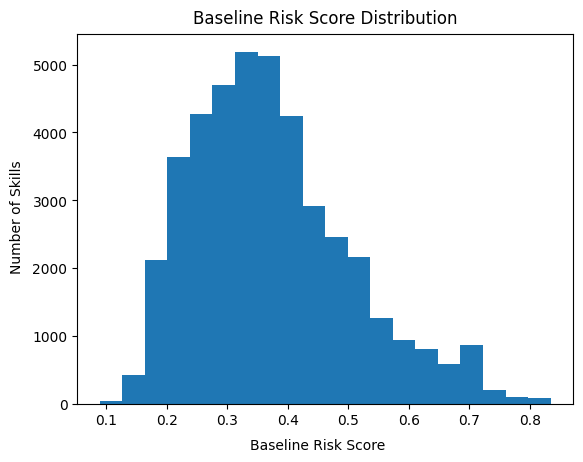

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("full_alexa_skills_with_baselines.csv")

fig, axes = plt.subplots(1, 1)

fig.supylabel('Number of Skills', fontsize=10)
fig.supxlabel('Baseline Risk Score', fontsize=10)

axes.hist(df["baseline_risk_score"], bins=20)
axes.set_title('Baseline Risk Score Distribution', fontsize=12, pad=8)
plt.show()